In [2]:
1+1

2


\[
\boxed{
\begin{aligned}
\textbf{Population proportion:}\qquad
&\pi\sim\operatorname{Beta}(1,1)
\\[4pt]
\textbf{Latent coding state:}\qquad
&Z_i\mid\pi\sim\operatorname{Bernoulli}(\pi)
\\[4pt]
\textbf{Non-coding model:}\qquad
&A_i\mid Z_i=0\sim f_{0i}
&&\text{(estimated from label shuffles)}
\\[4pt]
\textbf{Coding model:}\qquad
&A_i\mid Z_i=1\sim f_1
&&\text{(signal distribution to be inferred)}
\\[4pt]
\textbf{Observed-data likelihood:}\qquad
&p(A_i\mid\pi)
=(1-\pi)f_{0i}(A_i)+\pi f_1(A_i)
\\[4pt]
\textbf{Posterior outputs:}\qquad
&P(Z_i=1\mid D)
\\
&p(\pi\mid D)
\end{aligned}
}
\]
T

Now Bayes' rule gives
\[
\boxed{
p(\pi,\alpha_1,\beta_1,Z_1,\ldots,Z_N\mid A_1,\ldots,A_N)
\propto
\text{Likelihood}\times\text{Prior}.
}
\]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Figure 1N decoding results
# ------------------------------------------------------------

decoding = pd.read_csv(
    "../tables1/figure1N_all_subjects_decoding.csv"
)

# ------------------------------------------------------------
# Load Figure 1M permutation results
# ------------------------------------------------------------

perm = pd.read_csv(
    "../tables1/figure1M_all_neuron_permutations.csv"
)

print("Decoding table shape:")
print(decoding.shape)

print("\nPermutation table shape:")
print(perm.shape)

print("\nDecoding columns:")
print(decoding.columns.tolist())

print("\nPermutation columns:")
print(perm.columns.tolist())

display(perm.head())

Decoding table shape:
(554, 13)

Permutation table shape:
(552, 16)

Decoding columns:
['subject', 'neuron', 'region', 'mean_firing_rate_hz', 'n_presentations', 'min_class_count', 'n_splits', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'status', 'error']

Permutation columns:
['subject', 'neuron', 'region', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'n_presentations', 'n_splits', 'FR_null_mean', 'FR_p', 'FR_coding', 'TC_null_mean', 'TC_p', 'TC_coding', 'elapsed_seconds']


,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
0,YFF,9,ent,0.100917,0.165138,180,0.2,109,7,0.106376,0.646766,False,0.105092,0.059701,False,12.667940
1,YFF,10,hpc,0.091743,0.155963,90,0.2,109,7,0.106881,0.731343,False,0.109266,0.094527,False,11.077304
2,YFF,11,hpc,0.110092,0.201835,100,0.5,109,7,0.109404,0.532338,False,0.107248,0.019900,True,10.417088
3,YFF,12,hpc,0.100917,0.174312,300,0.5,109,7,0.110459,0.641791,False,0.108165,0.049751,True,11.636312
4,YFF,13,hpc,0.146789,0.155963,100,0.8,109,7,0.104771,0.159204,False,0.113257,0.139303,False,11.468347


In [3]:
# Keep successful neurons only if status exists
if "status" in decoding.columns:
    decoding_success = decoding[
        decoding["status"] == "success"
    ].copy()
else:
    decoding_success = decoding.copy()


A = decoding_success["TC_accuracy"].dropna()

print("Number of neurons:", len(A))
print()
print("Temporal decoding accuracy:")
print(f"Mean   = {100*A.mean():.2f}%")
print(f"Median = {100*A.median():.2f}%")
print(f"Min    = {100*A.min():.2f}%")
print(f"Max    = {100*A.max():.2f}%")

Number of neurons: 552

Temporal decoding accuracy:
Mean   = 14.58%
Median = 14.39%
Min    = 6.14%
Max    = 28.07%


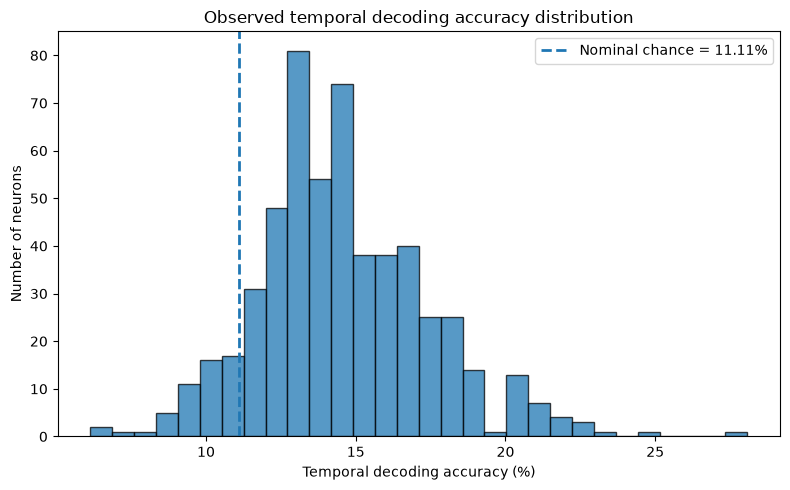

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(
    100 * A,
    bins=30,
    alpha=0.75,
    edgecolor="black"
)

plt.axvline(
    100/9,
    linestyle="--",
    linewidth=2,
    label="Nominal chance = 11.11%"
)

plt.xlabel("Temporal decoding accuracy (%)")
plt.ylabel("Number of neurons")
plt.title("Observed temporal decoding accuracy distribution")

plt.legend()
plt.tight_layout()
plt.show()

histogram represents our observed mixture:
\[
\boxed{
f(A)
=
(1-\pi)f_0(A)+\pi f_1(A)
}
\]
Conceptually,

In [7]:
import sys
import inspect
from pathlib import Path

# Project root is one level above notebooks1/
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python's import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Notebook location:", Path.cwd())
print("Project root:", PROJECT_ROOT)

# Now import
from src.number_decoding_analysis import permutation_test_decoding

# Print the function
print(inspect.getsource(permutation_test_decoding))

Notebook location: c:\Users\shafi\number-simplex-reproduction\notebooks1
Project root: c:\Users\shafi\number-simplex-reproduction


KeyboardInterrupt: 

In [ ]:
import inspect
from src.number_decoding_analysis import permutation_test_decoding

print(inspect.getsource(permutation_test_decoding))